# Proyecciones climáticas: tendencia y rangos de incertidumbre

**Geocomputación (1GEO20)** 

En este notebook practicamos dos herramientas para trabajar con series climáticas ya procesadas:

1. Un test de tendencia no paramétrico (Mann-Kendall) para saber si una serie de temperatura tiene una tendencia monótona significativa.
2. Cómo graficar series climáticas junto con su rango de incertidumbre.

**Datos:** Figura [SPM.8 (panel a)](https://www.ipcc.ch/report/ar6/wg1/figures/summary-for-policymakers/figure-spm-8) del *Summary for Policymakers* del IPCC AR6 (Grupo de Trabajo I), alojados en CEDA. Son series de la anomalía de temperatura superficial global (°C, referencia 1850-1900): una serie histórica observada (1950-2014) y cinco proyecciones futuras (2015-2099), una por cada escenario SSP. https://data.ceda.ac.uk/badc/ar6_wg1/data/spm/spm_08/v20210809/panel_a

Más información sobre los datos: https://catalogue.ceda.ac.uk/uuid/98af2184e13e4b91893ab72f301790db/

## ¿Qué son las columnas `5%`, `Mean` y `95%`?

Cada valor de temperatura en estos archivos no viene de un solo modelo climático, viene de un **ensamble** de modelos CMIP6 corridos bajo el mismo escenario.

- `Mean` es el valor central del ensamble para ese año.
- `5%` y `95%` son los percentiles 5 y 95 de la distribución de resultados entre modelos, lo que el IPCC llama el *rango muy probable* (*very likely range*).

Es decir, la banda entre `5%` y `95%` no es un margen de error estadístico de una sola medición: es la dispersión entre modelos, qué tanto coinciden o discrepan los distintos GCM del ensamble para ese año y ese escenario.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, theilslopes

## 1. Cargar los datos

Los 6 archivos comparten la misma estructura (`Year`, `5%`, `Mean`, `95%`), así que se cargan todos con el mismo bucle y se juntan en un solo DataFrame "largo", agregando una columna `escenario`.

In [ ]:
# Se define previamente una variable con la sección repetitiva de las rutas de datos
ruta = "https://raw.githubusercontent.com/SALINASSebas/geocomputacion_-1GEO20-/refs/heads/main/ejercicios/ejercicios_aplicados/data/climate_projections/tas_global_"

archivos = {
    "Historical": ruta + "Historical.csv",
    "SSP1-1.9":  ruta + "SSP1_1_9.csv",
    "SSP1-2.6":  ruta + "SSP1_2_6.csv",
    "SSP2-4.5":  ruta + "SSP2_4_5.csv",
    "SSP3-7.0":  ruta + "SSP3_7_0.csv",
    "SSP5-8.5":  ruta + "SSP5_8_5.csv",
}

# 'archivos' es un diccionario con dos items: el escenario y la dirección de los datos. Tienen la misma
# cantidad de elementos, por lo que el for se repetirá homogéneamente. 'partes' es una lista vacía. Por
# cada ruta se lee un df y se le asigna la columna "escenario" con la variable escenario correspondiente 
# definida en la iteración. Finalmente, los datos son agregados a la lista. 
partes = []
for escenario, ruta in archivos.items():
    df = pd.read_csv(ruta)
    df["escenario"] = escenario
    partes.append(df)

# Los datos son concatenados (colocados en un df uno por debajo de otro). El index se ignora para no 
# repetir números de índices
datos = pd.concat(partes, ignore_index=False)
datos.head()

,Year,5%,Mean,95%,escenario
0,1950.0,-0.060030,0.252242,0.608546,Historical
1,1951.0,-0.055686,0.274715,0.525308,Historical
2,1952.0,-0.042891,0.274303,0.540725,Historical
3,1953.0,-0.020530,0.253376,0.535419,Historical
4,1954.0,-0.127657,0.246369,0.553914,Historical


In [30]:
# Los datos se agrupan de acuerdo a la columna 'escenario'. Luego, se agarran los datos de la columna 
# 'Year' para hacer el análisis preliminar de los datos. El resultado agrupa los datos de cada escenario,
# por lo que solo hay 6 filas.
datos.groupby("escenario")["Year"].agg(["min", "max", "count"])

,min,max,count
escenario,,,
Historical,1950.0,2014.0,65
SSP1-1.9,2015.0,2099.0,85
SSP1-2.6,2015.0,2099.0,85
SSP2-4.5,2015.0,2099.0,85
SSP3-7.0,2015.0,2099.0,85
SSP5-8.5,2015.0,2099.0,85


## 2. Test de tendencia: Mann-Kendall

Mann-Kendall es un test no paramétrico: no asume que los datos siguen una distribución normal ni que la tendencia es lineal, solo evalúa si hay una tendencia **monótona** (siempre creciente o siempre decreciente).

Para esto se usarán las funciones de `scipy.stats`:

- `kendalltau(t, x)` calcula el coeficiente de correlación de Kendall (tau) entre el tiempo y la variable, junto con su p-valor. Probar si tau es significativamente distinto de 0 es matemáticamente equivalente al test de Mann-Kendall.
- `theilslopes(x, t)` calcula la **pendiente de Sen** (la mediana de las pendientes entre todos los pares de puntos, robusta a valores atípicos), junto con su propio intervalo de confianza.

In [35]:
# Se define una función de interpretación de resultados. el p_valor debe ser menor que alpha para que 
# exista una tendencia significativa. La dirección de la tendencia se define por el signo de tau.
def interpretar_tendencia(tau, p_valor, alpha=0.05):
    if p_valor < alpha and tau > 0:
        return "creciente"
    elif p_valor < alpha and tau < 0:
        return "decreciente"
    return "sin tendencia significativa"

In [ ]:
# Se seleccionan los datos del df 'datos' cuyo escenario pertenezca al grupo "Historical". La condición
# se define dentro de la llamada al df[...]
hist = datos[datos["escenario"] == "Historical"]

# Al usar kendalltau: Primero va la variable independiente y luego la dependiente
tau, p_valor = kendalltau(hist["Year"], hist["Mean"]) 

# Al usar theilslopes: Primero va la variable dependiente y luego la independiente. 'alpha' define el 
# intervalo de confianza. En este caso, emplea los datos por entre los cuantiles 2.5% y 97.5%. El dato 
# ubicado en los límites del intervalo se guardan en las variables ic_bajo e ic_alto
pendiente, intercepto, ic_bajo, ic_alto = theilslopes(hist["Mean"], hist["Year"], alpha=0.95) 

# Incluir 'f' antes del argumento en 'print()' permite escribir los datos no literales de las variables 
# escritas entre llaves {}. El elemento ':.xf' con x siendo un número entero define la cantidad de 
# decimales a escribir en la salida.
print(f"Serie histórica ({hist['Year'].min():.0f}-{hist['Year'].max():.0f})")
print(f"tau = {tau:.3f}, p-valor = {p_valor:.2e} -> {interpretar_tendencia(tau, p_valor)}")
# theilslopes() devuelve la pendiente en las unidades de "Year" (°C/año)
# el *10 convierte °C/año a °C/década, es una elección de presentación
print(f"Pendiente de Sen: {pendiente*10:.3f}°C/década (IC 95%: [{ic_bajo*10:.3f}, {ic_alto*10:.3f}])")

Serie histórica (1950-2014)
tau = 0.721, p-valor = 2.03e-17 -> creciente
Pendiente de Sen: 0.143°C/década (IC 95%: [0.123, 0.175])


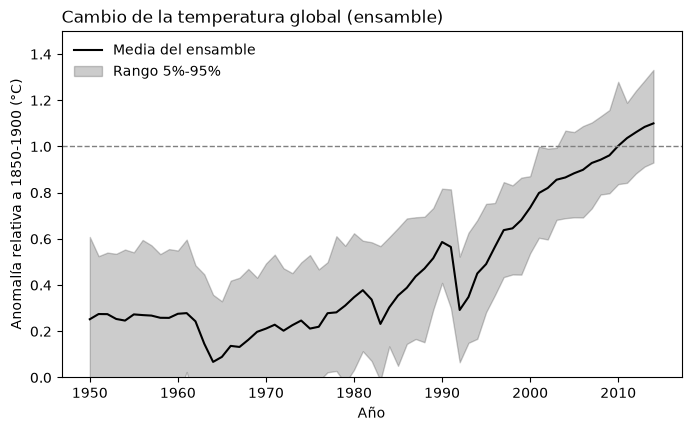

In [ ]:
# Define los mismos datos de la anterior variable en otra para no confundir
serie = datos[datos["escenario"] == "Historical"]

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(serie["Year"], serie["Mean"] , color="k", label="Media del ensamble")

# Toma los mismos argumentos de 'ax.plot()', pero se ingresan dos valores y: 'ax.fill_between(x, y1, y2)'
# los cuales definen el límite inferior y superior respectivamente.
ax.fill_between(serie["Year"], serie["5%"], serie["95%"],
                color="k", alpha=0.2, label="Rango 5%-95%")
# En el gráfico se agrega una línea horizontal en la posición del valor y definido. Su contraparte es 
# 'axvline' (vertical)
ax.axhline(1, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Año")
ax.set_ylabel("Anomalía relativa a 1850-1900 (°C)")
ax.set_title("Cambio de la temperatura global (ensamble)", loc="left")
# Define la existencia de un marco alrededor de la leyenda
ax.legend(frameon=False)
# Acorta la imagen entre los valores entregados para el eje y
ax.set_ylim(0, 1.5)
#plt.savefig("cambio_temperatura_global.png",dpi=300, bbox_inches='tight')
plt.show()

### Ejercicio 1

Completa la iteración para aplicar `kendalltau()` y `theilslopes()` a **cada uno de los 5 escenarios SSP** y arma una tabla resumen. Reemplaza los `...`.

In [52]:
resumen = []

for escenario in archivos.keys():
    serie = datos[datos["escenario"] == escenario]

    tau, p_valor = kendalltau(serie["Year"], serie["Mean"])
    pendiente, intercepto, ic_bajo, ic_alto = theilslopes(serie["Mean"], serie["Year"], alpha = 0.95)

    resumen.append({
        "escenario": escenario,
        "p_valor": p_valor,
        "pendiente_C_decada": pendiente*10,
        "tendencia": interpretar_tendencia(tau, p_valor),
    })

tabla_resumen = pd.DataFrame(resumen)
tabla_resumen

,escenario,p_valor,pendiente_C_decada,tendencia
0,Historical,2.029751e-17,0.143158,creciente
1,SSP1-1.9,7.568506e-02,-0.012079,sin tendencia significativa
2,SSP1-2.6,3.094553e-15,0.056751,creciente
3,SSP2-4.5,7.099489e-129,0.204456,creciente
4,SSP3-7.0,7.099489e-129,0.341600,creciente
5,SSP5-8.5,7.099489e-129,0.450291,creciente


## 3. Graficar rango de incertidumbre entre modelos

Usamos las columnas `5%` y `95%` para mostrar, junto a la media del ensamble, qué tan de acuerdo están los modelos entre sí. Cuanto más angosta la banda, mayor consenso entre modelos; cuanto más ancha, mayor incertidumbre.

In [ ]:
# Se definen periodos
periodos = {
    "Corto plazo": (2021, 2040),
    "Mediano plazo": (2041, 2060),
    "Largo plazo": (2081, 2100),
}

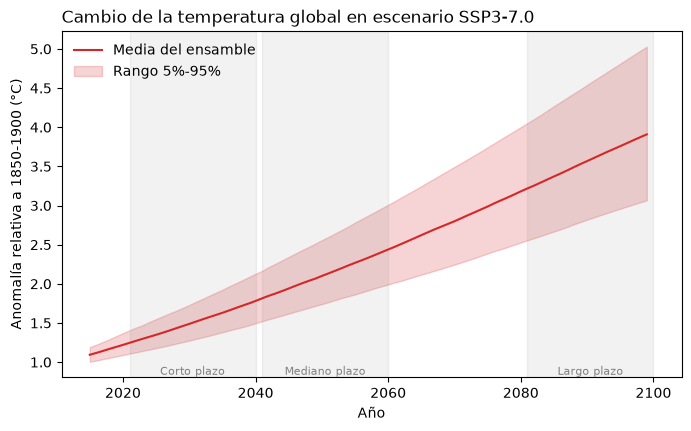

In [63]:
serie = datos[datos["escenario"] == "SSP3-7.0"]

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(serie["Year"], serie["Mean"], color="tab:red", label="Media del ensamble")
ax.fill_between(serie["Year"], serie["5%"], serie["95%"],
                color="tab:red", alpha=0.2, label="Rango 5%-95%")

# dictionary.items() llama a los elementos dentro de un diccionario. 
for etiqueta, (inicio, fin) in periodos.items():
    # Similar a axvline, axvspan coloca un rectángulo vertical en el gráfico. Su posición en el eje se
    # define por los primeros dos argumentos
    ax.axvspan(inicio, fin, color="grey", alpha=0.1)
    # Se agrega texto en la posición definida (en este caso: x1, x2, y)
    ax.text((inicio + fin)/2, ax.get_ylim()[0], etiqueta, ha="center", va="bottom", fontsize=8, color="grey") 
    #ha="center" alinea horizontalmente el texto al centro sobre el punto x
    #va="bottom" el punto y marca la base del texto (el texto queda arriba de y)

ax.set_xlabel("Año")
ax.set_ylabel("Anomalía relativa a 1850-1900 (°C)")
ax.set_title("Cambio de la temperatura global en escenario SSP3-7.0", loc="left")
# 'frameon=True' define el marco de la leyenda
ax.legend(frameon=False)
#plt.savefig("SSP3-7.0_media_ensamble.png",dpi=300, bbox_inches='tight')
plt.show()

### Ejercicio 2
Recrea una versión de la Figura SPM.8 (panel a) del IPCC, con las 6 series juntas. Usa esta paleta de colores (la misma que usa el IPCC en la figura original) y agrega banda de incertidumbre solo donde el diccionario dice `True`.

Completa la iteración con lo que falta.

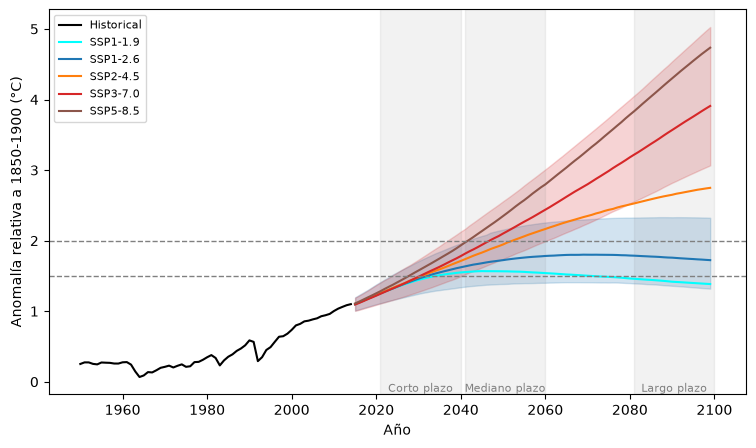

In [64]:
# Diccionarios dentro de diccionarios waaaa
estilo = {
    "Historical": {"color": "black",      "banda": False},
    "SSP1-1.9":   {"color": "cyan",       "banda": False},
    "SSP1-2.6":   {"color": "tab:blue",   "banda": True},
    "SSP2-4.5":   {"color": "tab:orange", "banda": False},
    "SSP3-7.0":   {"color": "tab:red",    "banda": True},
    "SSP5-8.5":   {"color": "tab:brown",  "banda": False},
}

fig, ax = plt.subplots(figsize=(9, 5))

# La llamada al item 'propiedades' toma los valores del diccionario adjunto al valor 'escenario' dentro
# de la variable 'estilo'. No se puede llamar directamente los diccionarios internos, se debe de agregar
# la columna del item deseado (ej. propiedades["color"])
for escenario, propiedades in estilo.items():
    serie = datos[datos["escenario"] == escenario]  # 1. filtra el escenario

    ax.plot(serie["Year"], serie["Mean"], color=propiedades["color"], label=escenario, lw=1.5)
    # Si no se especifica un valor para la condición, el condicional asume que debe ser 'True' para
    # ejecutar la siguiente instrucción
    if propiedades["banda"]:
        ax.fill_between(serie["Year"], serie["5%"], serie["95%"],  # 2. columnas de los límites
                         color=propiedades["color"], alpha=0.2)

# 3. agrega dos líneas horizontales de referencia en +1.5°C y +2°C (ax.axhline)
ax.axhline(1.5, color="gray", linestyle="--", linewidth=1)
ax.axhline(2, color="gray", linestyle="--", linewidth=1)

# 4. agrega bandas de periodos definidos por el IPCC
periodos = {
    "Corto plazo": (2021, 2040),
    "Mediano plazo": (2041, 2060),
    "Largo plazo": (2081, 2100),
}

for etiqueta, (inicio, fin) in periodos.items():
    ax.axvspan(inicio, fin, color="grey", alpha=0.1)
    ax.text((inicio + fin) / 2, ax.get_ylim()[0], etiqueta, ha="center", va="bottom", 
            fontsize=8, color="grey") 

ax.set_xlabel("Año")
ax.set_ylabel("Anomalía relativa a 1850-1900 (°C)")
ax.legend(fontsize=8)
plt.show()